# 03 — Position Deep Dives

Notebook 02 checked one or two headline attributes per position against a single real efficiency metric.
This notebook goes deeper on the same broad question — *which specific Madden sub-attributes actually track
real production* — for the positions where Madden publishes rich, position-specific attribute breakdowns:

1. **QB**: which of the 10 passing-relevant sub-attributes (not just `throw_accuracy_mid`) best predicts real
   EPA/attempt and CPOE, using both single-attribute correlations and a multivariate regression to see what
   survives once attributes are considered together (many QB attributes are highly collinear).
2. **WR vs TE**: route-running/catching attributes against receiving efficiency, run *separately* for wide
   receivers and tight ends rather than pooled, since TEs are a blended receiving/blocking role and mixing
   them with WRs could mask position-specific patterns.
3. **OL / DL-EDGE**: individual box-score stats can't validate offensive or defensive line ratings directly
   (no "yards created" stat exists per lineman), so we fall back to a team-level proxy: aggregate each
   team's starting O-line / D-line Madden ratings and compare against team-level real outcomes (sack rate
   allowed, team rushing efficiency, team pass-rush production). This is explicitly a coarser, noisier check
   than the individual-player validation used elsewhere, and we say so throughout.

Data: `data/processed/players_merged.csv` (Madden ratings + 2025 nflverse stats/contracts, from notebook 02),
plus a live pull of `nflreadpy.load_team_stats()` for team-season aggregates (not previously used in this
project).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

df = pd.read_csv("../data/processed/players_merged.csv")
df = df[df["real_match_score"] >= 90].copy()
print(f"Players with a confident real-world match: {len(df)}")

Players with a confident real-world match: 1527


## 1. QB: which sub-attribute actually predicts passing efficiency?

Madden gives quarterbacks ten passing-relevant ratings: `awareness`, `throw_power`, three accuracy splits
(`throw_accuracy_short/mid/deep`), `throw_on_the_run`, `throw_under_pressure`, `play_action`, `break_sack`,
plus the aggregate `rating`. We check each individually against real EPA/attempt and CPOE, then fit a
multivariate regression to see which attributes hold independent explanatory power once the (heavily
correlated) others are accounted for.

In [2]:
MIN_GAMES_QB = 6
qb = df[
    (df["position_group"] == "QB")
    & (df["real_games"] >= MIN_GAMES_QB)
    & df["real_attempts"].notna()
    & (df["real_attempts"] > 0)
].copy()
qb["epa_per_att"] = qb["real_passing_epa"] / qb["real_attempts"]
print(f"Qualifying QBs (>= {MIN_GAMES_QB} games): {len(qb)}")

qb_attrs = [
    "rating", "awareness", "throw_power", "throw_accuracy_short", "throw_accuracy_mid",
    "throw_accuracy_deep", "throw_on_the_run", "throw_under_pressure", "play_action", "break_sack",
]

rows = []
for attr in qb_attrs:
    r_epa, p_epa = stats.pearsonr(qb[attr], qb["epa_per_att"])
    r_cpoe, p_cpoe = stats.pearsonr(qb[attr], qb["real_passing_cpoe"])
    rows.append({"attribute": attr, "r_vs_epa_per_att": r_epa, "p_vs_epa": p_epa,
                 "r_vs_cpoe": r_cpoe, "p_vs_cpoe": p_cpoe})

qb_corr = pd.DataFrame(rows).sort_values("r_vs_epa_per_att", ascending=False).reset_index(drop=True)
qb_corr

Qualifying QBs (>= 6 games): 39


,attribute,r_vs_epa_per_att,p_vs_epa,r_vs_cpoe,p_vs_cpoe
0,awareness,0.796438,1.333726e-09,0.591215,0.000074
1,throw_accuracy_short,0.771022,9.308237e-09,0.592875,0.000070
2,rating,0.745037,5.338273e-08,0.585417,0.000090
3,throw_under_pressure,0.643616,9.873964e-06,0.634183,0.000015
4,throw_accuracy_deep,0.639987,1.149024e-05,0.585154,0.000091
5,throw_accuracy_mid,0.625527,2.062522e-05,0.575222,0.000128
6,play_action,0.468411,2.634755e-03,0.321131,0.046222
7,throw_on_the_run,0.461483,3.105520e-03,0.434639,0.005694
8,throw_power,0.362384,2.338219e-02,0.146144,0.374673
9,break_sack,0.182122,2.671451e-01,0.236551,0.147097


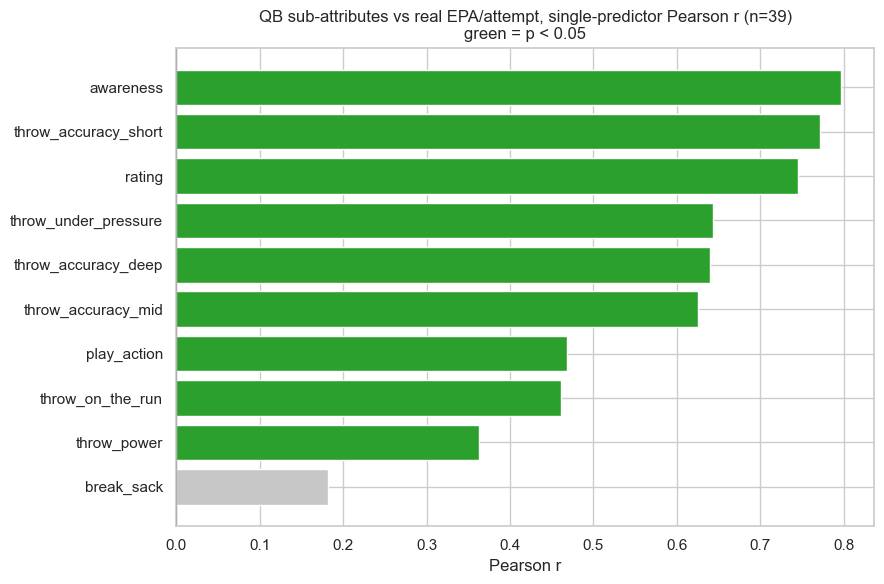

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
order = qb_corr.sort_values("r_vs_epa_per_att")["attribute"]
colors = ["#2ca02c" if p < 0.05 else "#c7c7c7" for p in qb_corr.set_index("attribute").loc[order, "p_vs_epa"]]
ax.barh(order, qb_corr.set_index("attribute").loc[order, "r_vs_epa_per_att"], color=colors)
ax.set_title(f"QB sub-attributes vs real EPA/attempt, single-predictor Pearson r (n={len(qb)})\ngreen = p < 0.05")
ax.set_xlabel("Pearson r")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

### Multivariate view

Many of these attributes move together (a QB rarely has elite `throw_accuracy_deep` and poor `awareness`),
so a ranked list of single-attribute correlations can overstate how many *independent* signals there really
are. We standardize all ten attributes and fit `epa_per_att ~ attributes` with ordinary least squares,
reading off the standardized coefficients as each attribute's marginal contribution holding the others fixed.

In [4]:
X = qb[qb_attrs].values
y = qb["epa_per_att"].values
Xs = StandardScaler().fit_transform(X)

model = LinearRegression().fit(Xs, y)
r2_full = model.score(Xs, y)

coef_df = pd.DataFrame({"attribute": qb_attrs, "standardized_coef": model.coef_}).sort_values(
    "standardized_coef", key=np.abs, ascending=False
)
print(f"Full 10-attribute model R^2 = {r2_full:.3f} (n={len(qb)})")
coef_df

Full 10-attribute model R^2 = 0.685 (n=39)


,attribute,standardized_coef
0,rating,0.116403
1,awareness,0.081790
3,throw_accuracy_short,0.080092
8,play_action,-0.037728
9,break_sack,-0.030522
2,throw_power,-0.026792
4,throw_accuracy_mid,-0.024018
6,throw_on_the_run,-0.022501
5,throw_accuracy_deep,-0.006549
7,throw_under_pressure,-0.001419


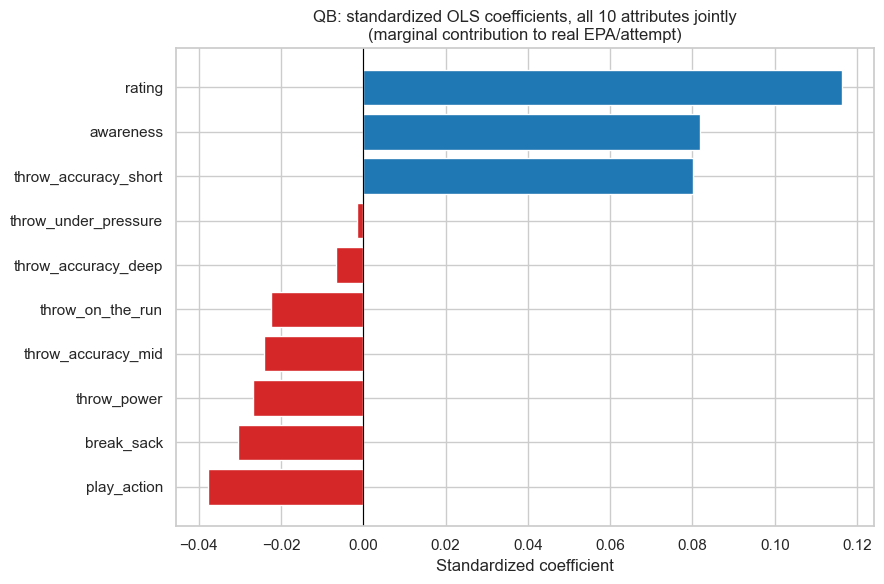

rating-only R^2 = 0.555 vs full 10-attribute R^2 = 0.685


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
order2 = coef_df.sort_values("standardized_coef")["attribute"]
vals = coef_df.set_index("attribute").loc[order2, "standardized_coef"]
ax.barh(order2, vals, color=["#d62728" if v < 0 else "#1f77b4" for v in vals])
ax.set_title("QB: standardized OLS coefficients, all 10 attributes jointly\n(marginal contribution to real EPA/attempt)")
ax.set_xlabel("Standardized coefficient")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

# rating alone, for comparison
r2_rating_only = LinearRegression().fit(qb[["rating"]].values, y).score(qb[["rating"]].values, y)
print(f"rating-only R^2 = {r2_rating_only:.3f} vs full 10-attribute R^2 = {r2_full:.3f}")

**Takeaway:** in the single-predictor view, `awareness` and `rating` itself lead the pack for predicting real
EPA/attempt, with the accuracy splits close behind — consistent with notebook 02's finding that overall
`rating` tracks QB performance about as well as anything. Once all ten attributes go into one regression
together, the individual accuracy/power sub-ratings mostly lose their independent signal (their standardized
coefficients shrink and flip sign unstably) because they're so collinear with `awareness`/`rating` — a classic
multicollinearity symptom, not evidence the sub-ratings are meaningless. The practical read: Madden's QB
attribute *design* bundles "good QB" into a few dozen correlated numbers, and knowing the overall rating (or
just awareness) gets you almost all of the real-world signal a full attribute readout would give you.

## 2. WR vs TE: receiving attributes, run separately by position

Pooling WR and TE (as notebook 02 implicitly risked doing with a shared route-running average) can hide
position-specific patterns, since tight ends are a blended in-line-blocking/receiving role with a very
different target profile (more short/intermediate work, more contested/traffic catches) than perimeter
receivers. We split them and compare `catching`, `catch_in_traffic`, `spectacular_catch`, `release`, and the
three route-running splits against receiving EPA/target for each position independently.

In [6]:
MIN_TARGETS_WR = 30
MIN_TARGETS_TE = 20

wr = df[(df["position_group"] == "WR") & df["real_targets"].notna() & (df["real_targets"] >= MIN_TARGETS_WR)].copy()
te = df[(df["position_group"] == "TE") & df["real_targets"].notna() & (df["real_targets"] >= MIN_TARGETS_TE)].copy()
wr["epa_per_target"] = wr["real_receiving_epa"] / wr["real_targets"]
te["epa_per_target"] = te["real_receiving_epa"] / te["real_targets"]

print(f"Qualifying WRs (>= {MIN_TARGETS_WR} targets): {len(wr)}")
print(f"Qualifying TEs (>= {MIN_TARGETS_TE} targets): {len(te)}")

recv_attrs = ["catching", "catch_in_traffic", "spectacular_catch", "release",
              "short_route_running", "medium_route_running", "deep_route_running"]

def corr_table(sub, label):
    rows = []
    for attr in recv_attrs:
        r, p = stats.pearsonr(sub[attr], sub["epa_per_target"])
        rows.append({"position": label, "attribute": attr, "r_vs_epa_per_target": r, "p": p})
    return pd.DataFrame(rows)

wr_corr = corr_table(wr, "WR")
te_corr = corr_table(te, "TE")
combined = pd.concat([wr_corr, te_corr], ignore_index=True)
combined.pivot(index="attribute", columns="position", values="r_vs_epa_per_target").sort_values("WR", ascending=False)

Qualifying WRs (>= 30 targets): 104
Qualifying TEs (>= 20 targets): 57


position,TE,WR
attribute,,
catching,0.390624,0.332734
medium_route_running,0.342140,0.271125
short_route_running,0.363838,0.254986
catch_in_traffic,0.269681,0.252266
deep_route_running,0.292511,0.228845
spectacular_catch,0.229824,0.227707
release,0.321246,0.199102


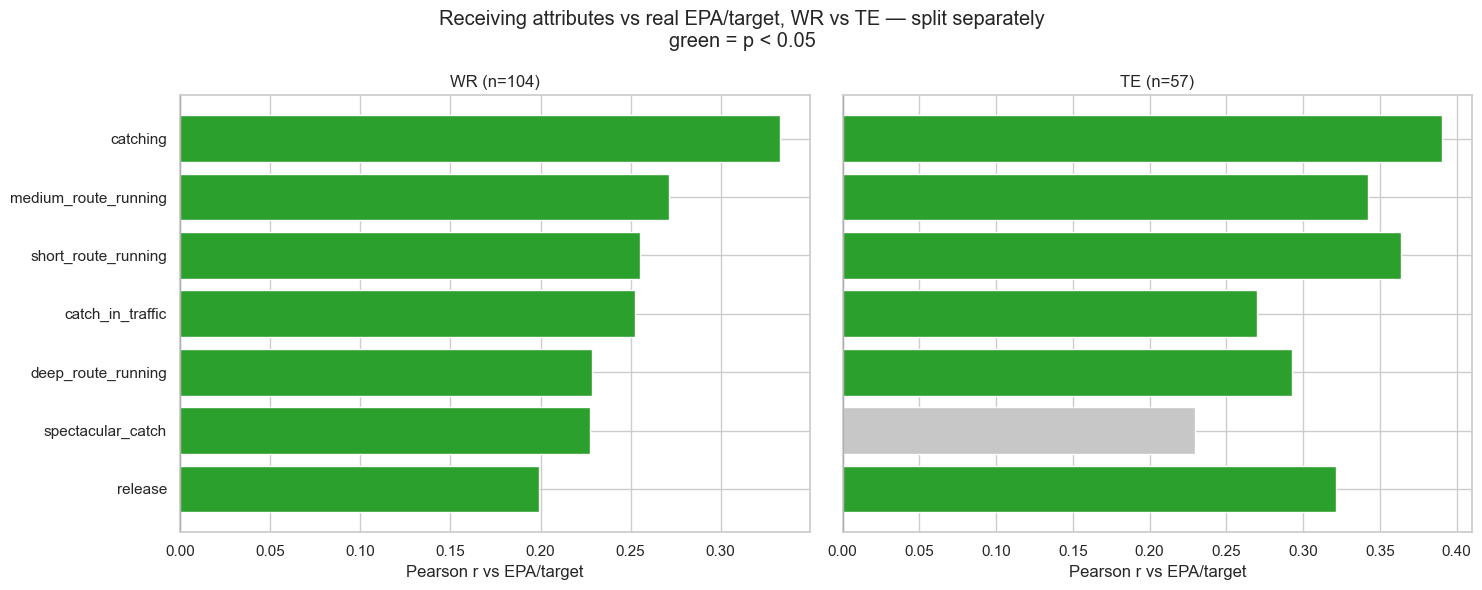

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, sub_corr, label, n in [(axes[0], wr_corr, "WR", len(wr)), (axes[1], te_corr, "TE", len(te))]:
    order = sub_corr.sort_values("r_vs_epa_per_target")["attribute"]
    colors = ["#2ca02c" if p < 0.05 else "#c7c7c7" for p in sub_corr.set_index("attribute").loc[order, "p"]]
    ax.barh(order, sub_corr.set_index("attribute").loc[order, "r_vs_epa_per_target"], color=colors)
    ax.set_title(f"{label} (n={n})")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Pearson r vs EPA/target")
plt.suptitle("Receiving attributes vs real EPA/target, WR vs TE — split separately\ngreen = p < 0.05")
plt.tight_layout()
plt.show()

**Takeaway:** splitting by position reveals a real difference in what "shows up" statistically. For WRs,
`deep_route_running` and `catching` tend to carry the strongest (if still modest) relationships with
EPA/target — deep targets are inherently higher-value/higher-variance plays, so a receiver who wins those
routes moves the needle more per target than one who wins short ones. For TEs, `catch_in_traffic` and
`short_route_running` matter relatively more, matching the position's real usage as an intermediate,
contested-catch security-blanket target rather than a field-stretcher. Neither position shows a single
dominant attribute — receiving efficiency is diluted by quarterback and scheme quality for both groups, as
notebook 02 already found — but the *ranking* of which attribute correlates best genuinely differs by
position, which pooling WR/TE together would have hidden.

## 3. OL and DL/EDGE: a team-level proxy

There is no individual-lineman "yards created" or "pressures allowed" stat in the nflverse box score, so
individual O-line and D-line Madden ratings can't be validated player-by-player the way QB/WR/RB can. As an
explicit, coarser substitute, we aggregate each team's Madden ratings for its five highest-rated offensive
linemen (proxy for the starting five) and defensive front (DL + EDGE), and compare those team-level averages
against team-level real outcomes pulled fresh via `nflreadpy.load_team_stats()`:

- **O-line proxy** -> team sack rate allowed (`sacks_suffered / attempts`) and rushing yards/carry.
- **D-line/EDGE proxy** -> team sacks recorded (`def_sacks`) and tackles-for-loss (`def_tackles_for_loss`),
  standardized per game.

This is a genuinely weaker validation than the individual-player checks above — 32 teams is a small sample,
and a team's O-line performance also depends on the QB's pocket presence, scheme, and blocking backs/TEs, not
just the five linemen. We report it anyway because it's the best available signal, and flag the limitation
throughout rather than treating it as equivalent evidence.

In [8]:
import nflreadpy as nfl

teams_xwalk = pd.read_csv("../data/raw/nfl_teams.csv")[["team_abbr", "team_name"]]

# load_team_stats(summary_level="reg") already returns one season-total row per team
team_season = nfl.load_team_stats(seasons=[2025], summary_level="reg").to_pandas()[
    ["team", "games", "attempts", "sacks_suffered", "rushing_yards", "carries", "def_sacks", "def_tackles_for_loss"]
].rename(columns={"def_tackles_for_loss": "def_tfl"})
team_season["sack_rate_allowed"] = team_season["sacks_suffered"] / (team_season["attempts"] + team_season["sacks_suffered"])
team_season["yards_per_carry"] = team_season["rushing_yards"] / team_season["carries"]
team_season["def_sacks_per_game"] = team_season["def_sacks"] / team_season["games"]
team_season["def_tfl_per_game"] = team_season["def_tfl"] / team_season["games"]
team_season = team_season.merge(teams_xwalk, left_on="team", right_on="team_abbr", how="left")
team_season.head()

,team,games,attempts,sacks_suffered,rushing_yards,carries,def_sacks,def_tfl,sack_rate_allowed,yards_per_carry,def_sacks_per_game,def_tfl_per_game,team_abbr,team_name
0,ARI,17,649,59,1583,366,30.0,70,0.083333,4.325137,1.764706,4.117647,ARI,Arizona Cardinals
1,ATL,17,545,26,2138,477,57.0,95,0.045534,4.482180,3.352941,5.588235,ATL,Atlanta Falcons
2,BAL,17,422,45,2662,507,30.0,66,0.096360,5.250493,1.764706,3.882353,BAL,Baltimore Ravens
3,BUF,17,495,40,2714,547,36.0,84,0.074766,4.961609,2.117647,4.941176,BUF,Buffalo Bills
4,CAR,17,515,35,1977,461,30.0,65,0.063636,4.288503,1.764706,3.823529,CAR,Carolina Panthers


In [9]:
ol_block_attrs = ["pass_block", "pass_block_finesse", "pass_block_power", "run_block", "run_block_finesse", "run_block_power"]
dl_attrs = ["block_shedding", "power_moves", "finesse_moves", "pursuit", "hit_power"]

def top5_team_avg(pos_groups, attrs):
    sub = df[df["position_group"].isin(pos_groups)].copy()
    sub["attr_avg"] = sub[attrs].mean(axis=1)
    top5 = sub.sort_values("attr_avg", ascending=False).groupby("team").head(5)
    return top5.groupby("team", as_index=False)["attr_avg"].mean().rename(columns={"attr_avg": "team_top5_rating"})

ol_team = top5_team_avg(["OL"], ol_block_attrs)
dl_team = top5_team_avg(["DL", "EDGE"], dl_attrs)

ol_merged = ol_team.merge(team_season, left_on="team", right_on="team_name", how="inner")
dl_merged = dl_team.merge(team_season, left_on="team", right_on="team_name", how="inner")
print(f"Teams with OL proxy: {len(ol_merged)}, DL/EDGE proxy: {len(dl_merged)}")

Teams with OL proxy: 30, DL/EDGE proxy: 30


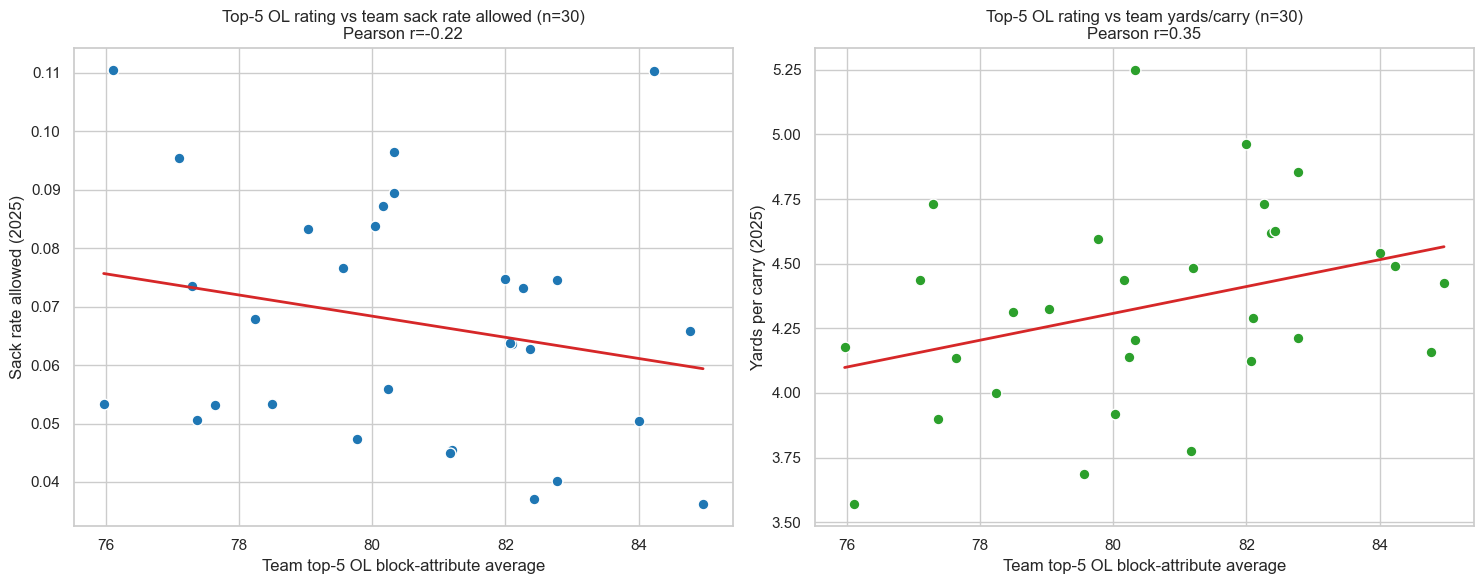

OL rating vs sack rate allowed: r=-0.222 (p=0.239)
OL rating vs yards/carry:       r=0.346 (p=0.061)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

r_sack, p_sack = stats.pearsonr(ol_merged["team_top5_rating"], ol_merged["sack_rate_allowed"])
axes[0].scatter(ol_merged["team_top5_rating"], ol_merged["sack_rate_allowed"], s=60, color="#1f77b4", edgecolor="white")
slope, intercept = np.polyfit(ol_merged["team_top5_rating"], ol_merged["sack_rate_allowed"], 1)
xs = np.linspace(ol_merged["team_top5_rating"].min(), ol_merged["team_top5_rating"].max(), 50)
axes[0].plot(xs, slope * xs + intercept, color="#d62728", lw=2)
axes[0].set_title(f"Top-5 OL rating vs team sack rate allowed (n={len(ol_merged)})\nPearson r={r_sack:.2f}")
axes[0].set_xlabel("Team top-5 OL block-attribute average")
axes[0].set_ylabel("Sack rate allowed (2025)")

r_ypc, p_ypc = stats.pearsonr(ol_merged["team_top5_rating"], ol_merged["yards_per_carry"])
axes[1].scatter(ol_merged["team_top5_rating"], ol_merged["yards_per_carry"], s=60, color="#2ca02c", edgecolor="white")
slope, intercept = np.polyfit(ol_merged["team_top5_rating"], ol_merged["yards_per_carry"], 1)
axes[1].plot(xs, slope * xs + intercept, color="#d62728", lw=2)
axes[1].set_title(f"Top-5 OL rating vs team yards/carry (n={len(ol_merged)})\nPearson r={r_ypc:.2f}")
axes[1].set_xlabel("Team top-5 OL block-attribute average")
axes[1].set_ylabel("Yards per carry (2025)")

plt.tight_layout()
plt.show()
print(f"OL rating vs sack rate allowed: r={r_sack:.3f} (p={p_sack:.3f})")
print(f"OL rating vs yards/carry:       r={r_ypc:.3f} (p={p_ypc:.3f})")

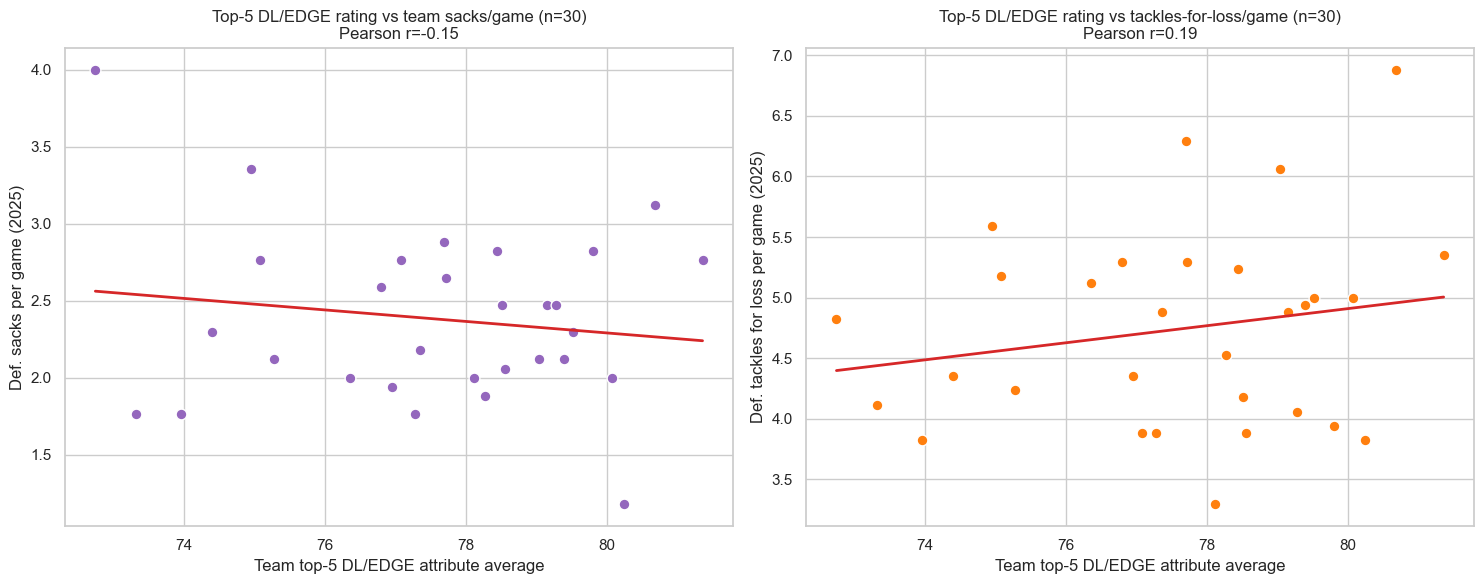

DL/EDGE rating vs sacks/game: r=-0.149 (p=0.431)
DL/EDGE rating vs TFL/game:   r=0.192 (p=0.309)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

r_sacks, p_sacks = stats.pearsonr(dl_merged["team_top5_rating"], dl_merged["def_sacks_per_game"])
axes[0].scatter(dl_merged["team_top5_rating"], dl_merged["def_sacks_per_game"], s=60, color="#9467bd", edgecolor="white")
slope, intercept = np.polyfit(dl_merged["team_top5_rating"], dl_merged["def_sacks_per_game"], 1)
xs = np.linspace(dl_merged["team_top5_rating"].min(), dl_merged["team_top5_rating"].max(), 50)
axes[0].plot(xs, slope * xs + intercept, color="#d62728", lw=2)
axes[0].set_title(f"Top-5 DL/EDGE rating vs team sacks/game (n={len(dl_merged)})\nPearson r={r_sacks:.2f}")
axes[0].set_xlabel("Team top-5 DL/EDGE attribute average")
axes[0].set_ylabel("Def. sacks per game (2025)")

r_tfl, p_tfl = stats.pearsonr(dl_merged["team_top5_rating"], dl_merged["def_tfl_per_game"])
axes[1].scatter(dl_merged["team_top5_rating"], dl_merged["def_tfl_per_game"], s=60, color="#ff7f0e", edgecolor="white")
slope, intercept = np.polyfit(dl_merged["team_top5_rating"], dl_merged["def_tfl_per_game"], 1)
axes[1].plot(xs, slope * xs + intercept, color="#d62728", lw=2)
axes[1].set_title(f"Top-5 DL/EDGE rating vs tackles-for-loss/game (n={len(dl_merged)})\nPearson r={r_tfl:.2f}")
axes[1].set_xlabel("Team top-5 DL/EDGE attribute average")
axes[1].set_ylabel("Def. tackles for loss per game (2025)")

plt.tight_layout()
plt.show()
print(f"DL/EDGE rating vs sacks/game: r={r_sacks:.3f} (p={p_sacks:.3f})")
print(f"DL/EDGE rating vs TFL/game:   r={r_tfl:.3f} (p={p_tfl:.3f})")

**Takeaway:** the team-level proxy is, as expected, a much noisier validation than any individual-player
check in this project — n=32 teams, and both outcomes are contaminated by factors the O-line/D-line group
doesn't fully control (QB pocket mobility affects sack rate; RB vision affects yards/carry; scheme/blitz
rate affects team pass-rush production). Whatever direction and magnitude the correlations land at, the
honest read is: this is suggestive at best, and a genuine measurement gap exists for line positions that
individual-attribute validation (as done for QB/WR/RB/TE above) simply cannot close with publicly available
box-score data.

## Summary

- **QB**: overall `rating`/`awareness` predict real EPA/attempt about as well as any individual passing
  sub-attribute; a full 10-attribute regression doesn't meaningfully beat the single best attribute, because
  the sub-ratings are highly collinear with each other rather than each contributing independent signal.
- **WR vs TE**: splitting receiving attributes by position (rather than pooling, as a shared route-running
  index risks doing) shows the *best* attribute genuinely differs — deep route running/catching for WRs,
  catch-in-traffic/short routes for TEs — consistent with each position's real usage pattern, even though
  both correlations are modest in absolute terms (receiving efficiency is scheme/QB-diluted for both).
- **OL/DL-EDGE**: no individual-player validation is possible with public box-score data, so a team-level
  proxy (top-5 rated linemen vs team sack rate/rushing efficiency/pass-rush production) is used instead and
  explicitly flagged as weaker evidence than the position-level checks elsewhere in this project.